In [31]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go

%matplotlib inline

In [32]:
mat_path = Path("../data/example1kinect.mat")

print(mat_path.exists())

True


In [33]:
mat = scipy.io.loadmat(mat_path)

print("All keys inside the .mat file:")
print(mat.keys())

All keys inside the .mat file:
dict_keys(['__header__', '__version__', '__globals__', 'amplitudes1', 'distances1', 'cloud1'])


In [34]:
A = mat["amplitudes1"]
D = mat["distances1"]
PC = mat["cloud1"]

print("A shape:", A.shape, "dtype:", A.dtype)
print("D shape:", D.shape, "dtype:", D.dtype)
print("PC shape:", PC.shape, "dtype:", PC.dtype)

A shape: (424, 512) dtype: uint16
D shape: (424, 512) dtype: float64
PC shape: (424, 512, 3) dtype: float64


In [35]:
A_img = np.squeeze(A)
D_img = np.squeeze(D)

print("A_img shape:", A_img.shape)
print("D_img shape:", D_img.shape)

A_img shape: (424, 512)
D_img shape: (424, 512)


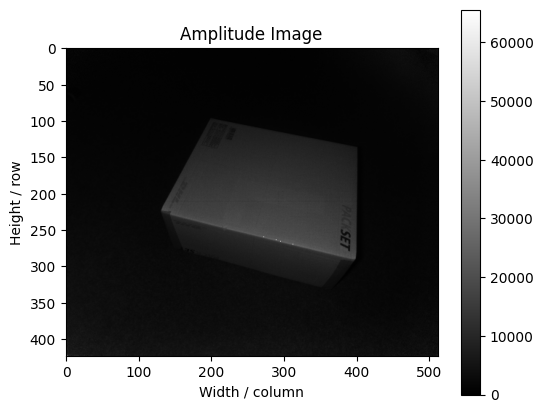

In [36]:
plt.figure(figsize=(6, 5))
plt.imshow(A_img, cmap="gray")
plt.title("Amplitude Image")
plt.xlabel("Width / column")
plt.ylabel("Height / row")
plt.colorbar()
plt.show()

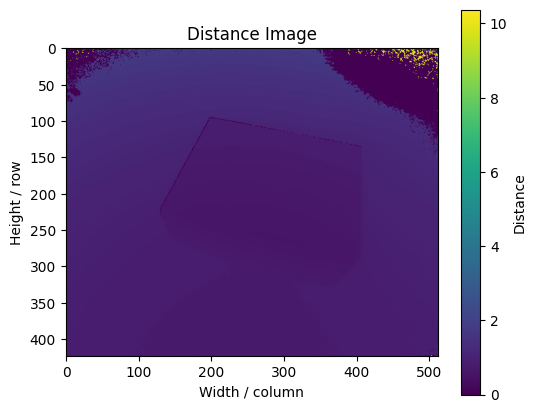

In [37]:
plt.figure(figsize=(6, 5))
plt.imshow(D_img, cmap="viridis")
plt.title("Distance Image")
plt.xlabel("Width / column")
plt.ylabel("Height / row")
plt.colorbar(label="Distance")
plt.show()

In [38]:
row = 50
col = 50

print("Amplitude at pixel:", A[row, col])
print("Distance at pixel:", D[row, col])
print("3D point at pixel:", PC[row, col, :])

Amplitude at pixel: 1099
Distance at pixel: 1.5265097618103027
3D point at pixel: [-0.69758737 -0.51824576  1.255     ]


In [39]:
X = PC[:, :, 0]
Y = PC[:, :, 1]
Z = PC[:, :, 2]

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Z shape:", Z.shape)

print("X min/max:", np.nanmin(X), np.nanmax(X))
print("Y min/max:", np.nanmin(Y), np.nanmax(Y))
print("Z min/max:", np.nanmin(Z), np.nanmax(Z))

X shape: (424, 512)
Y shape: (424, 512)
Z shape: (424, 512)
X min/max: -1.0650511980056763 1.2287603616714478
Y min/max: -0.9771229028701782 0.4742830693721771
Z min/max: 0.0 1.8000001907348633


In [40]:
step = 5  # increase to 10 if plotting is slow

X_sub = X[::step, ::step]
Y_sub = Y[::step, ::step]
Z_sub = Z[::step, ::step]
D_sub = D_img[::step, ::step]

x = X_sub.ravel()
y = Y_sub.ravel()
z = Z_sub.ravel()
colors = D_sub.ravel()

# valid 3D points: finite values and positive depth
valid = (
    np.isfinite(x) &
    np.isfinite(y) &
    np.isfinite(z) &
    (z > 0)
)

x = x[valid]
y = y[valid]
z = z[valid]
colors = colors[valid]

print("Number of plotted points:", len(x))
print("x range:", np.min(x), np.max(x))
print("y range:", np.min(y), np.max(y))
print("z range:", np.min(z), np.max(z))

Number of plotted points: 8055
x range: -1.001882791519165 1.2287603616714478
y range: -0.9736195802688599 0.4151177704334259
z range: 0.5680000185966492 1.667999505996704


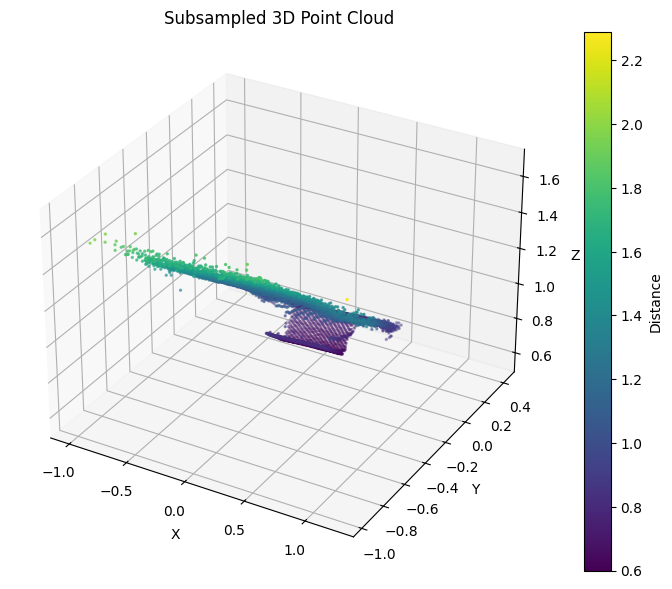

In [41]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    x,
    y,
    z,
    c=colors,
    s=2,
    cmap="viridis"
)

ax.set_title("Subsampled 3D Point Cloud")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.colorbar(sc, label="Distance")
plt.show()

In [42]:
print("Amplitude min:", np.nanmin(A_img))
print("Amplitude max:", np.nanmax(A_img))

print("Distance min:", np.nanmin(D_img))
print("Distance max:", np.nanmax(D_img))

print("Number of zero distances:", np.sum(D_img == 0))
print("Number of positive distances:", np.sum(D_img > 0))

Amplitude min: 0
Amplitude max: 65535
Distance min: 0.0
Distance max: 10.372331619262695
Number of zero distances: 14459
Number of positive distances: 202629


Valid distance count: 202629
Valid distance min: 0.5980724096298218
Valid distance max: 10.372331619262695
Valid distance mean: 0.9824830781108075


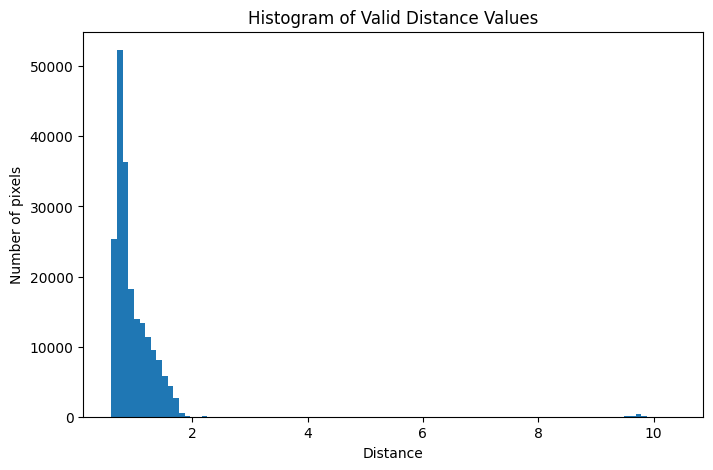

In [43]:
D_valid = D_img[np.isfinite(D_img) & (D_img > 0)]

print("Valid distance count:", len(D_valid))
print("Valid distance min:", np.min(D_valid))
print("Valid distance max:", np.max(D_valid))
print("Valid distance mean:", np.mean(D_valid))

plt.figure(figsize=(8, 5))
plt.hist(D_valid.ravel(), bins=100)
plt.title("Histogram of Valid Distance Values")
plt.xlabel("Distance")
plt.ylabel("Number of pixels")
plt.show()

Zoomed valid count: 201931
Zoomed min: 0.5980724096298218
Zoomed max: 1.997454285621643


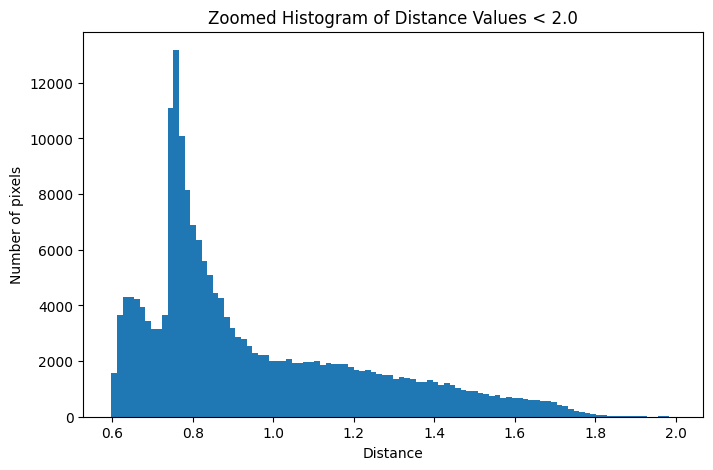

In [44]:
# Keep only reasonable distances for visualization
D_valid_zoom = D_valid[D_valid < 2.0]

print("Zoomed valid count:", len(D_valid_zoom))
print("Zoomed min:", np.min(D_valid_zoom))
print("Zoomed max:", np.max(D_valid_zoom))

plt.figure(figsize=(8, 5))
plt.hist(D_valid_zoom.ravel(), bins=100)
plt.title("Zoomed Histogram of Distance Values < 2.0")
plt.xlabel("Distance")
plt.ylabel("Number of pixels")
plt.show()

In [45]:
percentiles = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]

for p in percentiles:
    value = np.percentile(D_valid_zoom, p)
    print(f"{p:>2}% percentile: {value:.4f}")

 1% percentile: 0.6141
 5% percentile: 0.6418
10% percentile: 0.6755
20% percentile: 0.7449
30% percentile: 0.7670
40% percentile: 0.7994
50% percentile: 0.8474
60% percentile: 0.9243
70% percentile: 1.0531
80% percentile: 1.2009
90% percentile: 1.3941
95% percentile: 1.5303
99% percentile: 1.7050


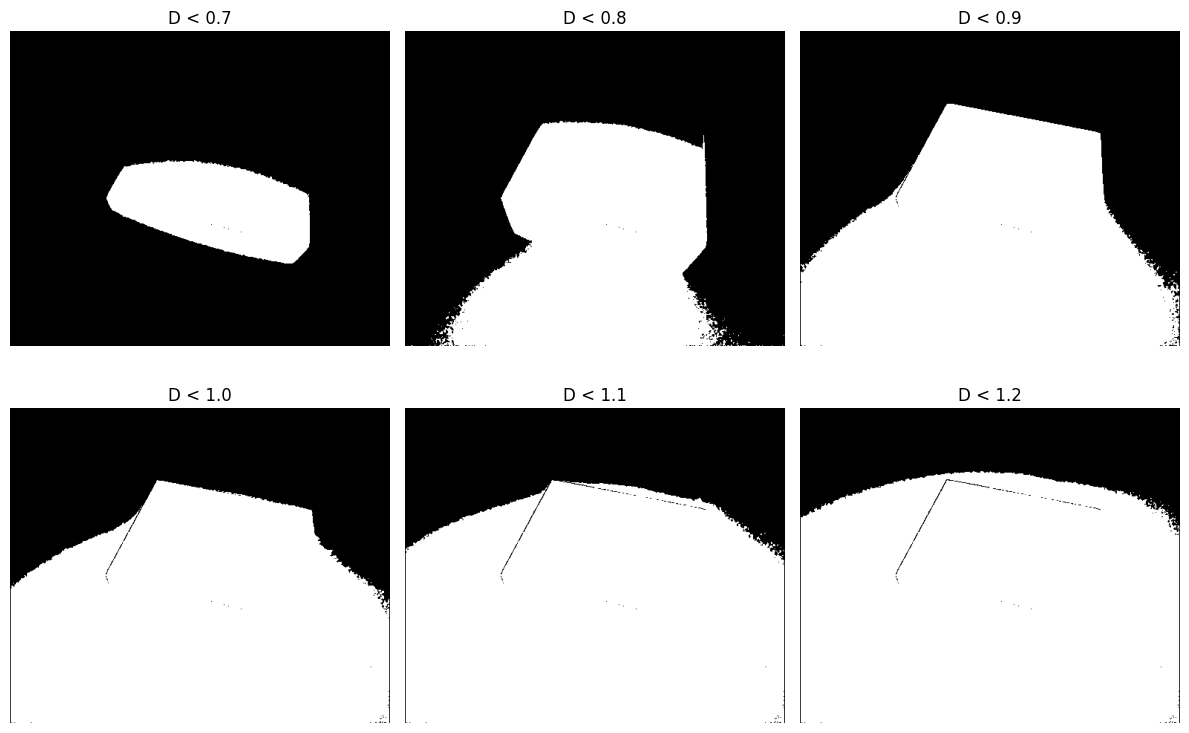

In [46]:
thresholds = [0.70, 0.80, 0.90, 1.00, 1.10, 1.20]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, threshold in zip(axes, thresholds):
    mask = (D_img > 0) & (D_img < threshold)

    ax.imshow(mask, cmap="gray")
    ax.set_title(f"D < {threshold}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Selected threshold: 0.76
Mask shape: (424, 512)
Number of selected pixels: 53703
Percentage selected: 24.73789431014151 %


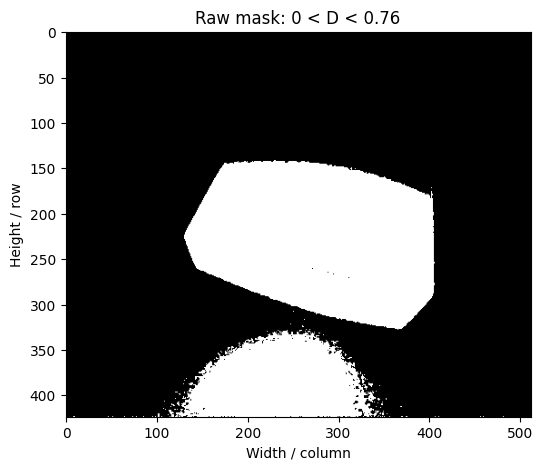

In [61]:
selected_threshold = 0.76

mask_raw = (D_img > 0) & (D_img < selected_threshold)

print("Selected threshold:", selected_threshold)
print("Mask shape:", mask_raw.shape)
print("Number of selected pixels:", np.sum(mask_raw))
print("Percentage selected:", 100 * np.sum(mask_raw) / mask_raw.size, "%")

plt.figure(figsize=(6, 5))
plt.imshow(mask_raw, cmap="gray")
plt.title(f"Raw mask: 0 < D < {selected_threshold}")
plt.xlabel("Width / column")
plt.ylabel("Height / row")
plt.show()